# Visión por Computador — Clase: Fundamentos con OpenCV + NumPy

**Objetivo de la sesión**: Entender qué es una imagen, trabajar con **espacios de color** (RGB/BGR vs **HSV**), aplicar **filtrado por color**, detectar **bordes** (Sobel y **Canny**) y practicar **transformaciones morfológicas** (erosión, dilatación, apertura, cierre).

> Basado en ideas del repo *ComputerVision_Basics/Chapter 1* (Andy Guzmán), con teoría breve y práctica guiada.


## Prerrequisitos

- Python 3.x
- Librerías: `opencv-python` (`cv2`), `numpy`, `matplotlib`, `Pillow`

Instalación (si hace falta):  
```bash
pip install opencv-python numpy matplotlib pillow
```


In [1]:
!pip install opencv-python numpy matplotlib pillow

  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl (44.0 MB)


## 1. ¿Qué es una imagen?

- Para el ordenador, una imagen es una **matriz** (o tensor) de píxeles.
- Una imagen **RGB/BGR** tiene forma `(alto, ancho, 3)`, una por canal.
- En OpenCV, el orden por defecto es **BGR**, no RGB.


In [3]:
import cv2, numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
ASSETS = Path('cv_assets')

def imshow_rgb(title, img_bgr, size=5):
    """Muestra una imagen BGR (cv2) como RGB en matplotlib."""
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(size, size))
    plt.title(title)
    plt.axis('off')
    plt.imshow(img_rgb)
    plt.show()

print('Assets en:', ASSETS)
print('Archivos:', list(ASSETS.iterdir()))


Assets en: cv_assets
Archivos: [WindowsPath('cv_assets/Filtering.png'), WindowsPath('cv_assets/hsv_demo.png'), WindowsPath('cv_assets/Resources'), WindowsPath('cv_assets/test_image_1.jpg'), WindowsPath('cv_assets/test_img_b.jpg'), WindowsPath('cv_assets/world.png')]


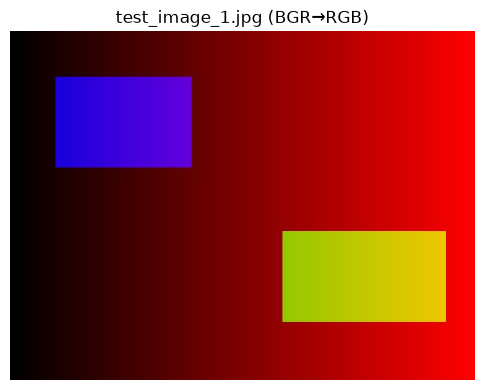

In [4]:
img1 = cv2.imread(str(ASSETS/'test_image_1.jpg'))
imshow_rgb('test_image_1.jpg (BGR→RGB)', img1, size=6)

## 2. Espacios de color: BGR/RGB vs HSV

- **RGB/BGR**: tres canales que mezclan Rojo, Verde y Azul (OpenCV usa BGR).
- **HSV**: Tono (*Hue*), Saturación (*Saturation*), Valor (*Value*). Facilita seleccionar colores por **rango de tono**.
- El canal **Hue** en OpenCV está en `[0, 179]` (no 0..360).

Visualicemos un gradiente *HSV (Hue en X, Value en Y, Saturación fija)*:


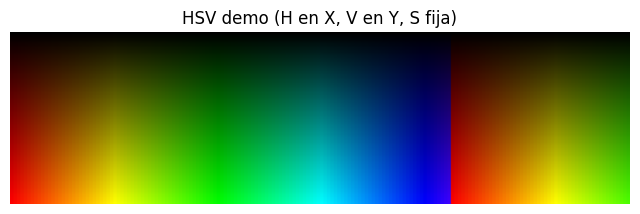

In [5]:
from PIL import Image
hsv_demo = cv2.imread(str(ASSETS/'hsv_demo.png'))  # BGR
imshow_rgb('HSV demo (H en X, V en Y, S fija)', hsv_demo, size=8)

## 3. Filtrado por color (HSV)

**Idea:** Convertimos la imagen a **HSV** y definimos rangos `min`/`max` para un color concreto. Luego creamos una **máscara binaria** con `cv2.inRange` y la aplicamos a la imagen original con `cv2.bitwise_and`.

Ejemplo con una imagen de círculos R/G/B:


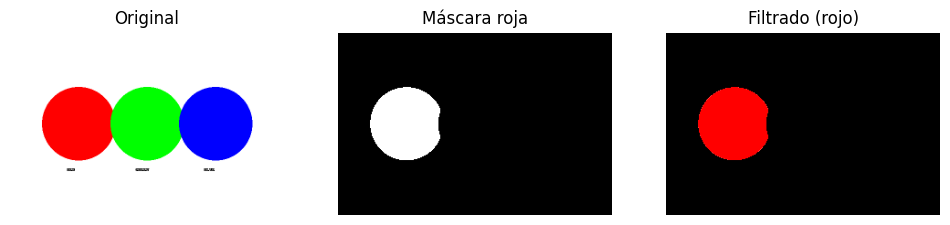

In [10]:
img = cv2.imread(str(ASSETS/'Filtering.png'))
img = cv2.resize(img, (300, 200), interpolation=cv2.INTER_AREA)

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Rango para ROJO (aprox. H ~ 0/2=0 y H ~ 180/2=90 en OpenCV; pero nuestra imagen es muy saturada/iluminada)
min_red1= np.array([0, 150, 150], dtype=np.uint8)
max_red1 = np.array([10, 255, 255], dtype=np.uint8)

min_red2= np.array([170, 150, 150], dtype=np.uint8)
max_red2 = np.array([180, 255, 255], dtype=np.uint8)

mask_r1 = cv2.inRange(hsv, min_red1, max_red1)
mask_r2 = cv2.inRange(hsv, min_red2, max_red2)



mask_r  = cv2.bitwise_or(mask_r1, mask_r2)
res_r  = cv2.bitwise_and(img, img, mask=mask_r)

# Mostrar resultados
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title('Original')
plt.subplot(1,3,2); plt.imshow(mask_r, cmap='gray'); plt.axis('off'); plt.title('Máscara roja')
plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(res_r, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title('Filtrado (rojo)')
plt.show()


**Ejercicio rápido:** Cambia los rangos para detectar **rojo** y **azul**. Recuerda que en HSV (OpenCV) el rojo suele estar en dos rangos de `Hue` debido al *wrap-around* (por ejemplo `[0,10]` y `[170,179]`).

## 4. Detección de bordes — Sobel

- Los **bordes** son cambios bruscos de intensidad.
- **Sobel** aproxima la **derivada** en X e Y con **convolución** usando kernels de 3×3 (o 5×5).
- Magnitud del gradiente: `mag = sqrt(Sx^2 + Sy^2)`.

### 4.1. Sobel con funciones de OpenCV


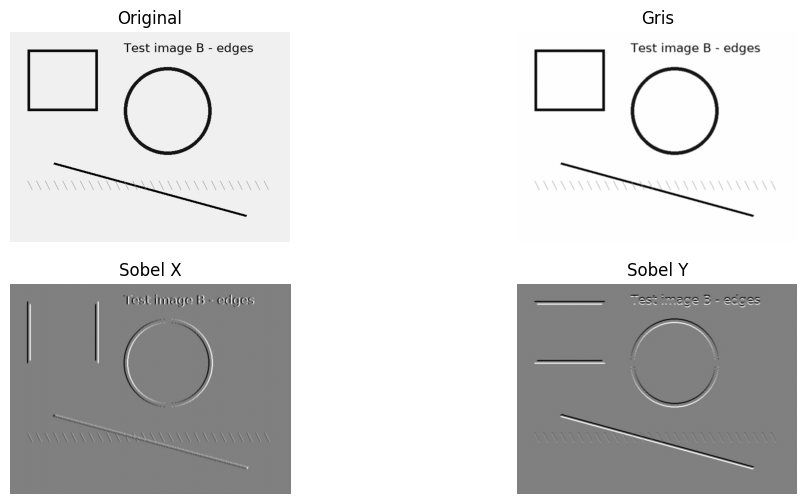

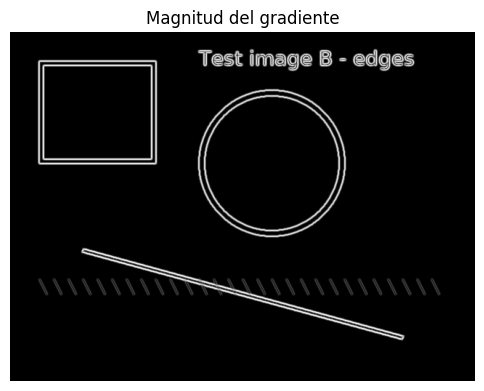

In [ ]:
imgb = cv2.imread(str(ASSETS/'test_img_b.jpg'))
gray = cv2.cvtColor(imgb, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (3,3), 0)

sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
mag = np.sqrt(sobelx**2 + sobely**2)
mag = (255 * (mag / (mag.max() + 1e-8))).astype(np.uint8)

plt.figure(figsize=(12,6))
plt.subplot(2,2,1); plt.imshow(cv2.cvtColor(imgb, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title('Original')
plt.subplot(2,2,2); plt.imshow(gray, cmap='gray'); plt.axis('off'); plt.title('Gris')
plt.subplot(2,2,3); plt.imshow(sobelx, cmap='gray'); plt.axis('off'); plt.title('Sobel X')
plt.subplot(2,2,4); plt.imshow(sobely, cmap='gray'); plt.axis('off'); plt.title('Sobel Y')
plt.show()

plt.figure(figsize=(6,5))
plt.imshow(mag, cmap='gray'); plt.axis('off'); plt.title('Magnitud del gradiente')
plt.show()


### 4.2. Sobel replicado con `filter2D` (convolución explícita)

Definimos los **kernels** Sobel y usamos `cv2.filter2D` para aplicarlos manualmente.


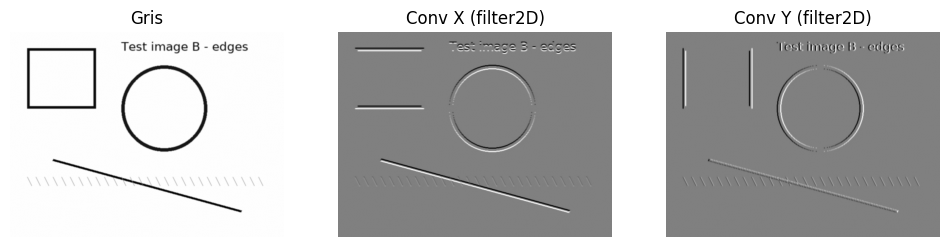

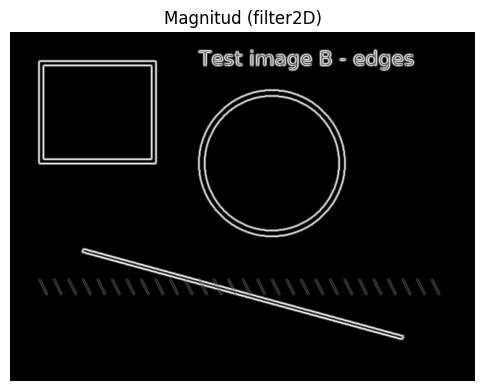

In [ ]:
kernel_x = np.array([[-1,-2,-1],
                     [ 0, 0, 0],
                     [ 1, 2, 1]], dtype=np.float32)
kernel_y = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]], dtype=np.float32)

x_conv = cv2.filter2D(gray, cv2.CV_64F, kernel_x)
y_conv = cv2.filter2D(gray, cv2.CV_64F, kernel_y)
mag2 = np.sqrt(x_conv**2 + y_conv**2)
mag2 = (255 * (mag2 / (mag2.max() + 1e-8))).astype(np.uint8)

plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.axis('off'); plt.title('Gris')
plt.subplot(1,3,2); plt.imshow(x_conv, cmap='gray'); plt.axis('off'); plt.title('Conv X (filter2D)')
plt.subplot(1,3,3); plt.imshow(y_conv, cmap='gray'); plt.axis('off'); plt.title('Conv Y (filter2D)')
plt.show()

plt.figure(figsize=(6,5))
plt.imshow(mag2, cmap='gray'); plt.axis('off'); plt.title('Magnitud (filter2D)')
plt.show()


## 5. Detección de bordes — Canny

**Canny** es un pipeline clásico:
1) Suavizado (Gauss) → 2) Gradiente (Sobel) → 3) *Non-Max Suppression* → 4) **Histeresis** (dos umbrales).

Probemos con distintos umbrales mínimos/máximos:


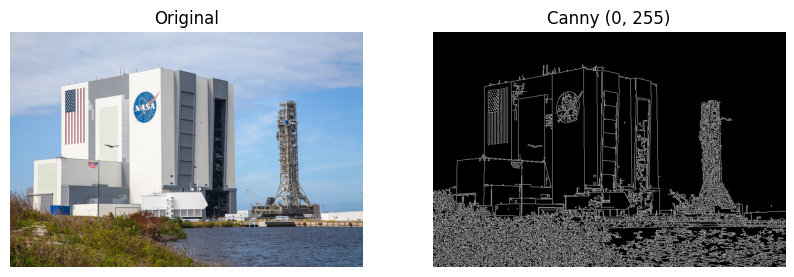

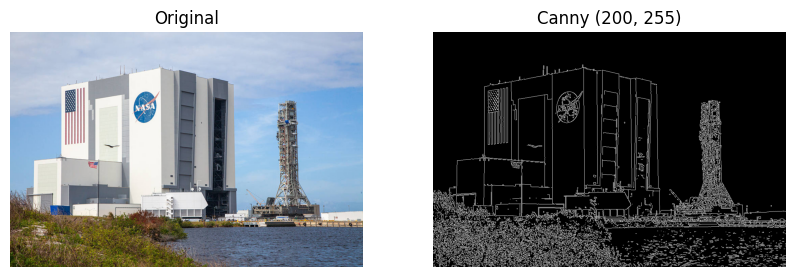

In [19]:
def canny_show(img_bgr, minV, maxV):
    edges = cv2.Canny(img_bgr, minV, maxV)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title('Original')
    plt.subplot(1,2,2); plt.imshow(edges, cmap='gray'); plt.axis('off'); plt.title(f'Canny ({minV}, {maxV})')
    plt.show()
imgb = cv2.imread(str(ASSETS/'test_img_b.jpg'))
canny_show(imgb, 0, 255)
canny_show(imgb, 200, 255)


## 6. Transformaciones morfológicas (en binario)

- **Erosión**: "come" píxeles blancos (útil para eliminar puntos blancos finos).
- **Dilatación**: expande píxeles blancos (rellena huecos pequeños).
- **Apertura** = Erosión → Dilatación (elimina **ruido blanco**).
- **Cierre** = Dilatación → Erosión (rellena **huecos** y elimina **ruido negro**).

Probamos sobre una imagen sintética con puntos ruidosos:


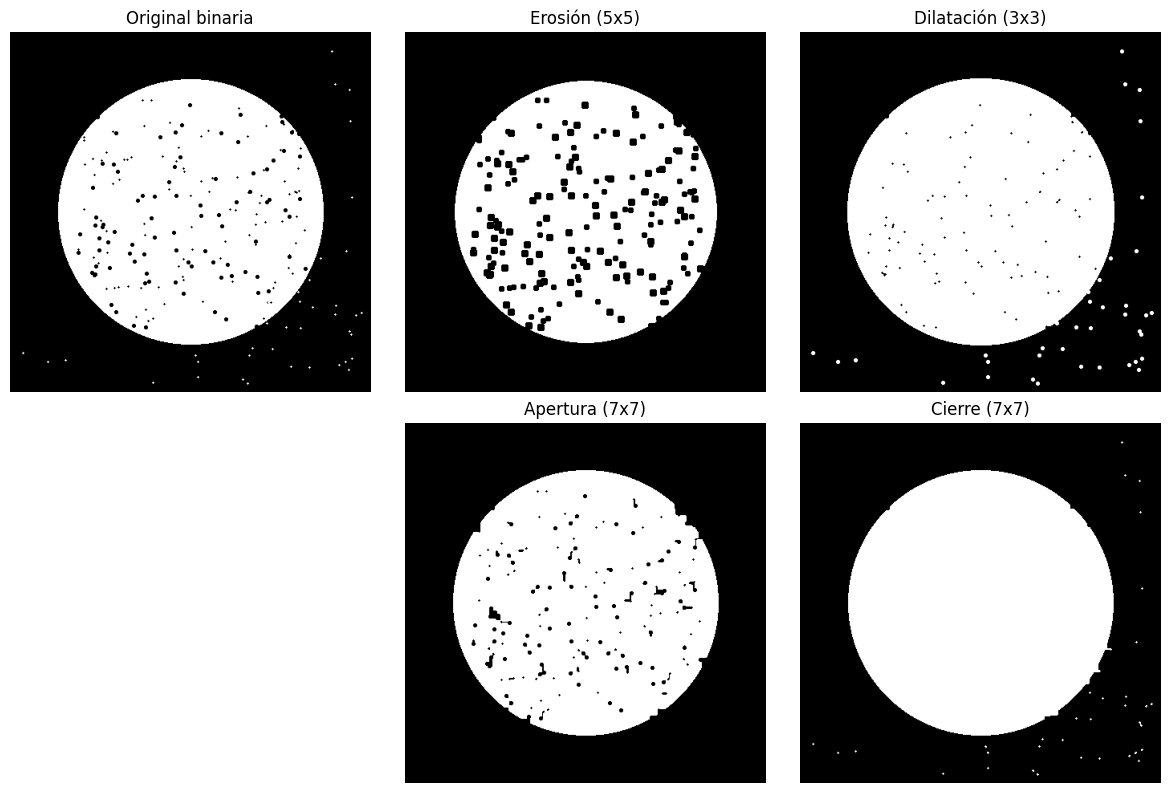

In [ ]:
bin_img = cv2.imread(str(ASSETS/'world.png'), cv2.IMREAD_GRAYSCALE)
_, bin_thresh = cv2.threshold(bin_img, 127, 255, cv2.THRESH_BINARY)

k1 = np.ones((5,5), np.uint8)
k2 = np.ones((3,3), np.uint8)
k3 = np.ones((7,7), np.uint8)
k4 = np.ones((20,20), np.uint8)

erosion  = cv2.erode(bin_thresh, k1, iterations=1)
dilation = cv2.dilate(bin_thresh, k2, iterations=1)
opening  = cv2.morphologyEx(bin_thresh, cv2.MORPH_OPEN, k3)
closing  = cv2.morphologyEx(bin_thresh, cv2.MORPH_CLOSE, k3)

plt.figure(figsize=(12,8))
plt.subplot(2,3,1); plt.imshow(bin_thresh, cmap='gray'); plt.axis('off'); plt.title('Original binaria')
plt.subplot(2,3,2); plt.imshow(erosion,  cmap='gray'); plt.axis('off'); plt.title('Erosión (5x5)')
plt.subplot(2,3,3); plt.imshow(dilation, cmap='gray'); plt.axis('off'); plt.title('Dilatación (3x3)')
plt.subplot(2,3,5); plt.imshow(opening,  cmap='gray'); plt.axis('off'); plt.title('Apertura (7x7)')
plt.subplot(2,3,6); plt.imshow(closing,  cmap='gray'); plt.axis('off'); plt.title('Cierre (7x7)')
plt.tight_layout()
plt.show()


## 7. Mini-ejercicios (rápidos)

1. **Pixelado**: reduce tamaño con `cv2.resize(img, (w//s, h//s), interpolation=cv2.INTER_AREA)` y vuelve a escalar arriba con `INTER_NEAREST`.
2. **Gradiente**: calcula `mag = sqrt(Sx^2 + Sy^2)` y normalízalo a 0..255 (ya lo hicimos). Prueba `ksize=5`.
3. **Composición con máscara**: crea una máscara circular suave y mezcla `img` y una versión `blur` con:  
   `comp = img * a + blur * (1-a)` (recuerda escalar `a` a [0,1] y *broadcasting* en canales).

¡Muéstralo con matplotlib!

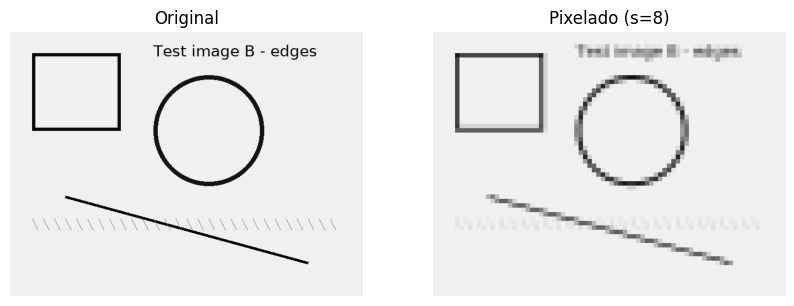

In [ ]:

img = cv2.imread(str(ASSETS/'test_img_b.jpg')) 
h, w = img.shape[:2]


s = 8   


small = cv2.resize(img, (w//s, h//s), interpolation=cv2.INTER_AREA)


pixelated = cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)


plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title('Original')
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(pixelated, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title(f'Pixelado (s={s})')
plt.show()


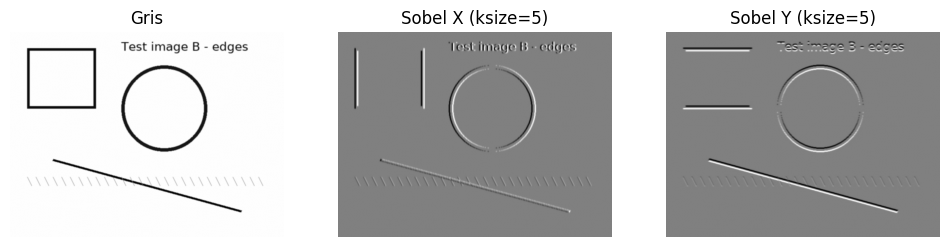

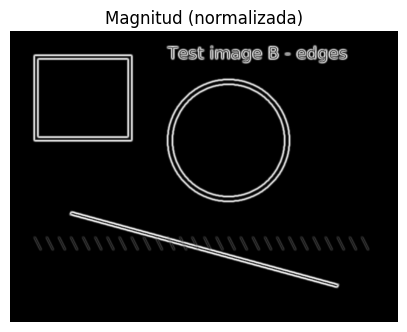

In [ ]:

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (3,3), 0)


Sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
Sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)


mag = np.sqrt(Sx**2 + Sy**2)
mag = (255 * (mag / (mag.max() + 1e-8))).astype(np.uint8)


plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.axis('off'); plt.title('Gris')
plt.subplot(1,3,2); plt.imshow(Sx, cmap='gray'); plt.axis('off'); plt.title('Sobel X (ksize=5)')
plt.subplot(1,3,3); plt.imshow(Sy, cmap='gray'); plt.axis('off'); plt.title('Sobel Y (ksize=5)')
plt.show()

plt.figure(figsize=(5,4))
plt.imshow(mag, cmap='gray'); plt.axis('off'); plt.title('Magnitud (normalizada)')
plt.show()


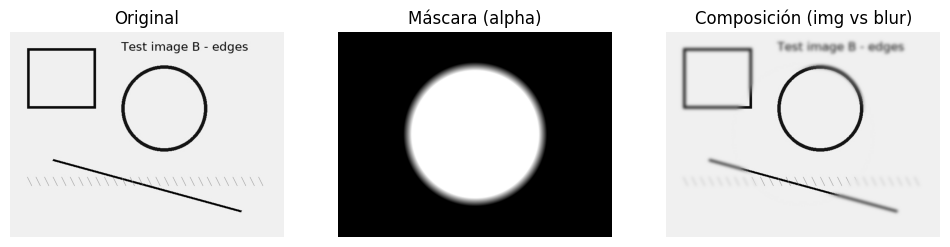

In [ ]:

blur = cv2.GaussianBlur(img, (21,21), 0)


h, w = img.shape[:2]
Y, X = np.ogrid[:h, :w]
cy, cx = h//2, w//2
radius = int(min(h, w) * 0.35)


dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
edge_width = max(1, int(0.12 * radius)) 
a = np.clip((radius - dist) / edge_width, 0, 1).astype(np.float32) 


a3 = a[..., None]  # (h,w,1)


comp = (img.astype(np.float32) * a3 + blur.astype(np.float32) * (1.0 - a3)).astype(np.uint8)


plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(img,  cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title('Original')
plt.subplot(1,3,2); plt.imshow(a, cmap='gray'); plt.axis('off'); plt.title('Máscara (alpha)')
plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(comp, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title('Composición (img vs blur)')
plt.show()
